# 08 Business-Oriented Threshold Selection

This notebook turns the tuned fraud model into a decision policy.

The model still outputs a fraud risk score. The business question is where to put the threshold, given that false negatives are more expensive than false positives.


## Setup

Run the full labelled training data with the same time-based validation split used in the earlier notebooks.

Three models are compared:

- `v2_full_reference`: the original notebook 06 `v2_full` XGBoost setup
- `tuned_params_no_class_weight`: the same tuned hyperparameters, but without extra fraud-class weighting
- `tuned_cost_sensitive_xgb`: the best notebook 07 configuration, rerun on the full data


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.data_prep_safe import RAW_DIR, load_merged_data_safe, make_time_validation_split
from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme
from src.fraud_detection.metrics import compute_classification_metrics
from src.fraud_detection.tree_preprocessing_v2 import fit_tree_preprocessor_v2, transform_tree_preprocessor_v2

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42
FN_COST = 20
FP_COST = 1
MODEL_COLORS = {
    "v2_full_reference": "#2563eb",
    "tuned_params_no_class_weight": "#64748b",
    "tuned_cost_sensitive_xgb": "#dc2626",
}
MODEL_ORDER = ["v2_full_reference", "tuned_params_no_class_weight", "tuned_cost_sensitive_xgb"]
THRESHOLDS = np.unique(
    np.r_[
        np.linspace(0.001, 0.050, 50),
        np.linspace(0.055, 0.500, 90),
        np.linspace(0.510, 0.990, 49),
    ]
)
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "business_threshold_selection_summary.json"


## Data Size


In [2]:
def count_csv_rows(path: Path) -> int:
    with path.open("rb") as handle:
        return max(0, sum(1 for _ in handle) - 1)


data_size = pd.DataFrame(
    [
        {
            "table": "train_transaction",
            "rows": count_csv_rows(RAW_DIR / "train_transaction.csv"),
            "label": "labelled transactions",
        },
        {
            "table": "train_identity",
            "rows": count_csv_rows(RAW_DIR / "train_identity.csv"),
            "label": "identity rows matched by TransactionID",
        },
        {
            "table": "test_transaction",
            "rows": count_csv_rows(RAW_DIR / "test_transaction.csv"),
            "label": "unlabelled Kaggle test transactions",
        },
        {
            "table": "test_identity",
            "rows": count_csv_rows(RAW_DIR / "test_identity.csv"),
            "label": "identity rows matched by TransactionID",
        },
    ]
)
display(data_size.style.hide(axis="index"))


table,rows,label
train_transaction,590540,labelled transactions
train_identity,144233,identity rows matched by TransactionID
test_transaction,506691,unlabelled Kaggle test transactions
test_identity,141907,identity rows matched by TransactionID


## Full-Data Time Split And `v2_full` Features


In [3]:
train_df, test_df = load_merged_data_safe(nrows=None)
train_part, valid_part = make_time_validation_split(train_df)

artifacts = fit_tree_preprocessor_v2(
    train_part,
    add_missing_indicators=True,
    add_group_amount_features=True,
    drop_missing_threshold=0.999,
)

x_train = transform_tree_preprocessor_v2(train_part, artifacts, impute_numeric=False)
x_valid = transform_tree_preprocessor_v2(valid_part, artifacts, impute_numeric=False)
y_train = train_part["isFraud"].to_numpy()
y_valid = valid_part["isFraud"].to_numpy()

positive_count = int(y_train.sum())
negative_count = int(len(y_train) - positive_count)
base_scale_pos_weight = negative_count / max(1, positive_count)

split_summary = pd.DataFrame(
    [
        ["labelled_train_rows", len(train_df)],
        ["kaggle_test_rows", len(test_df)],
        ["time_split_train_rows", len(train_part)],
        ["time_split_valid_rows", len(valid_part)],
        ["train_fraud_rate", y_train.mean()],
        ["valid_fraud_rate", y_valid.mean()],
        ["v2_full_feature_count", x_train.shape[1]],
        ["base_scale_pos_weight", base_scale_pos_weight],
    ],
    columns=["item", "value"],
)
display(split_summary.style.hide(axis="index"))

def feature_group_summary(artifacts):
    feature_columns = artifacts.feature_columns
    known_groups = {
        "time_features": [
            "TransactionHour",
            "TransactionDay",
            "TransactionWeek",
            "TransactionDayOfWeek",
        ],
        "amount_transforms": [
            "TransactionAmt_log1p",
            "TransactionAmt_cents",
        ],
        "missing_indicators": [
            col for col in feature_columns if col.endswith("__missing")
        ],
        "count_encoded_categoricals": [
            f"{col}__count"
            for col in artifacts.count_encode_cols
            if f"{col}__count" in feature_columns
        ],
        "group_amount_deviation": [
            col
            for col in feature_columns
            if col.startswith("TransactionAmt_diff_mean_")
            or col.startswith("TransactionAmt_to_mean_")
            or col.startswith("TransactionAmt_z_")
        ],
        "binary_match_flags": [
            col for col in feature_columns if col.endswith("_bin")
        ],
    }
    assigned = set().union(*[set(cols) for cols in known_groups.values()])
    rows = []
    for group, cols in known_groups.items():
        rows.append(
            {
                "feature_group": group,
                "count": len(cols),
                "examples": ", ".join(cols[:6]),
            }
        )

    raw_like = [col for col in feature_columns if col not in assigned]
    rows.append(
        {
            "feature_group": "raw_numeric_and_original_signals",
            "count": len(raw_like),
            "examples": ", ".join(raw_like[:6]),
        }
    )
    return pd.DataFrame(rows)


feature_inventory = feature_group_summary(artifacts)
display(feature_inventory.style.hide(axis="index"))


item,value
labelled_train_rows,590540.000000
kaggle_test_rows,506691.000000
time_split_train_rows,472432.000000
time_split_valid_rows,118108.000000
train_fraud_rate,0.035135
valid_fraud_rate,0.034409
v2_full_feature_count,807.000000
base_scale_pos_weight,27.461474


feature_group,count,examples
time_features,4,"TransactionHour, TransactionDay, TransactionWeek, TransactionDayOfWeek"
amount_transforms,2,"TransactionAmt_log1p, TransactionAmt_cents"
missing_indicators,330,"D10__missing, D11__missing, D12__missing, D13__missing, D14__missing, D15__missing"
count_encoded_categoricals,47,"DeviceInfo__count, DeviceInfo_device__count, DeviceType__count, M1__count, M2__count, M3__count"
group_amount_deviation,15,"TransactionAmt_diff_mean_card1, TransactionAmt_to_mean_card1, TransactionAmt_z_card1, TransactionAmt_diff_mean_card4, TransactionAmt_to_mean_card4, TransactionAmt_z_card4"
binary_match_flags,8,"M1_bin, M2_bin, M3_bin, M5_bin, M6_bin, M7_bin"
raw_numeric_and_original_signals,401,"TransactionDT, TransactionAmt, card1, card2, card3, card5"


## Fit Full-Data Reference And Tuned Models


In [4]:
def make_xgb(params):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )


model_configs = {
    "v2_full_reference": {
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
    },
    "tuned_params_no_class_weight": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": 1.0,
    },
    "tuned_cost_sensitive_xgb": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": base_scale_pos_weight * 0.65,
    },
}

fitted_models = {}
score_by_model = {}
train_score_by_model = {}
metric_rows = []
generalization_rows = []

for model_name, params in model_configs.items():
    model = make_xgb(params)
    model.fit(x_train, y_train)
    train_scores = model.predict_proba(x_train)[:, 1]
    scores = model.predict_proba(x_valid)[:, 1]

    fitted_models[model_name] = model
    train_score_by_model[model_name] = train_scores
    score_by_model[model_name] = scores

    train_metrics = compute_classification_metrics(
        y_train,
        train_scores,
        top_fractions=(0.01, 0.03, 0.05),
    )
    valid_metrics = compute_classification_metrics(
        y_valid,
        scores,
        top_fractions=(0.01, 0.03, 0.05),
    )
    for split_name, split_metrics in [("train", train_metrics), ("validation", valid_metrics)]:
        generalization_rows.append(
            {
                "model": model_name,
                "split": split_name,
                "roc_auc": split_metrics["roc_auc"],
                "pr_auc_average_precision": split_metrics["average_precision"],
                "precision_at_top_3pct": split_metrics["precision_at_top_3pct"],
                "recall_at_top_3pct": split_metrics["recall_at_top_3pct"],
                "precision_at_top_5pct": split_metrics["precision_at_top_5pct"],
                "recall_at_top_5pct": split_metrics["recall_at_top_5pct"],
            }
        )
    metric_rows.append(
        {
            "model": model_name,
            "scale_pos_weight": params.get("scale_pos_weight", 1.0),
            "roc_auc": valid_metrics["roc_auc"],
            "pr_auc_average_precision": valid_metrics["average_precision"],
            "precision_at_top_1pct": valid_metrics["precision_at_top_1pct"],
            "recall_at_top_1pct": valid_metrics["recall_at_top_1pct"],
            "precision_at_top_3pct": valid_metrics["precision_at_top_3pct"],
            "recall_at_top_3pct": valid_metrics["recall_at_top_3pct"],
            "precision_at_top_5pct": valid_metrics["precision_at_top_5pct"],
            "recall_at_top_5pct": valid_metrics["recall_at_top_5pct"],
            "accuracy_at_0_50": valid_metrics["accuracy"],
            "precision_at_0_50": valid_metrics["precision"],
            "recall_at_0_50": valid_metrics["recall"],
        }
    )

model_metrics = pd.DataFrame(metric_rows).sort_values("pr_auc_average_precision", ascending=False)
generalization_metrics = pd.DataFrame(generalization_rows)
display(model_metrics.style.hide(axis="index"))


model,scale_pos_weight,roc_auc,pr_auc_average_precision,precision_at_top_1pct,recall_at_top_1pct,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct,accuracy_at_0_50,precision_at_0_50,recall_at_0_50
tuned_params_no_class_weight,1.000000,0.924168,0.583864,0.902707,0.262549,0.601016,0.524114,0.433796,0.630413,0.975666,0.809896,0.382628
tuned_cost_sensitive_xgb,17.849958,0.921506,0.569229,0.892555,0.259596,0.586061,0.511073,0.423976,0.616142,0.958301,0.426548,0.615157
v2_full_reference,1.000000,0.911789,0.553101,0.895093,0.260335,0.569413,0.496555,0.411954,0.598671,0.975091,0.800966,0.367372


## Train vs Validation Generalization Check

The Kaggle test set has no labels, so this check uses the time-based validation split as the holdout set.

A large train-validation gap would suggest overfitting. A small gap with weak scores would suggest underfitting. Here we mainly want strong validation ranking metrics without an extreme gap.


model,split,roc_auc,pr_auc_average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct
v2_full_reference,train,0.961792,0.798864,0.816270,0.696970,0.556896,0.792518
v2_full_reference,validation,0.911789,0.553101,0.569413,0.496555,0.411954,0.598671
tuned_params_no_class_weight,train,0.982879,0.885701,0.909335,0.776432,0.612988,0.872342
tuned_params_no_class_weight,validation,0.924168,0.583864,0.601016,0.524114,0.433796,0.630413
tuned_cost_sensitive_xgb,train,0.993736,0.914317,0.909970,0.776975,0.644230,0.916802
tuned_cost_sensitive_xgb,validation,0.921506,0.569229,0.586061,0.511073,0.423976,0.616142


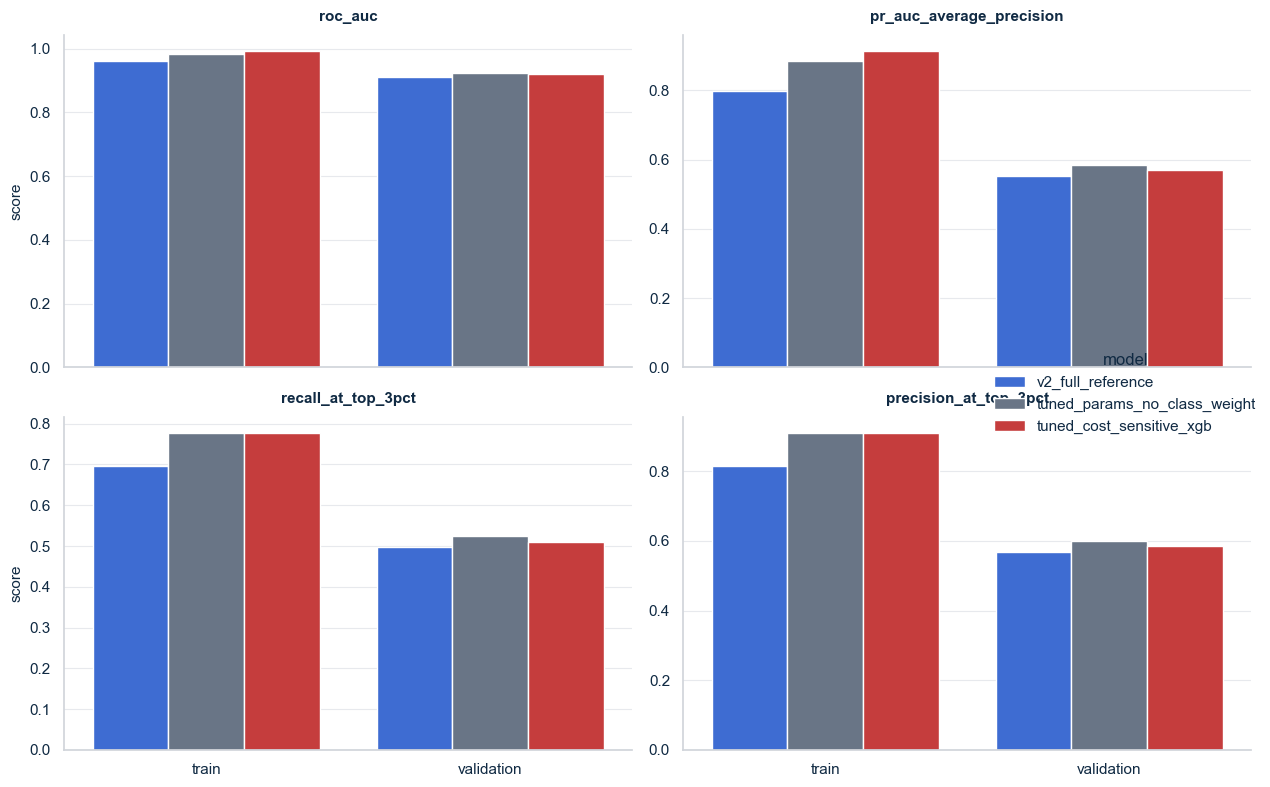

In [5]:
display(generalization_metrics.style.hide(axis="index"))

generalization_plot = generalization_metrics.melt(
    id_vars=["model", "split"],
    value_vars=["roc_auc", "pr_auc_average_precision", "recall_at_top_3pct", "precision_at_top_3pct"],
    var_name="metric",
    value_name="value",
)

g = sns.catplot(
    data=generalization_plot,
    x="split",
    y="value",
    hue="model",
    col="metric",
    kind="bar",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    col_wrap=2,
    height=4,
    aspect=1.25,
    sharey=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("", "score")
plt.tight_layout()
plt.show()


## Cost-Optimized Threshold

The default threshold `0.50` is not necessarily a good operating point for fraud.

Here the selected threshold minimizes expected validation cost:

`total_cost = FN_COST * false_negatives + FP_COST * false_positives`

The default setting below treats one missed fraud as 20 times more expensive than one false alarm.


In [6]:
def threshold_policy_table(y_true, y_score, model_name, thresholds=THRESHOLDS, fn_cost=FN_COST, fp_cost=FP_COST):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    rows = []

    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)

        tp = int(np.sum((y_pred == 1) & (y_true == 1)))
        fp = int(np.sum((y_pred == 1) & (y_true == 0)))
        fn = int(np.sum((y_pred == 0) & (y_true == 1)))
        tn = int(np.sum((y_pred == 0) & (y_true == 0)))

        total_cost = fn_cost * fn + fp_cost * fp
        rows.append(
            {
                "model": model_name,
                "threshold": float(threshold),
                "true_positives": tp,
                "false_positives": fp,
                "false_negatives": fn,
                "true_negatives": tn,
                "precision": tp / max(1, tp + fp),
                "recall": tp / max(1, tp + fn),
                "false_positive_rate": fp / max(1, fp + tn),
                "false_negative_rate": fn / max(1, tp + fn),
                "review_rate": (tp + fp) / len(y_true),
                "total_cost": total_cost,
                "cost_per_1k_txn": total_cost / len(y_true) * 1000,
            }
        )

    return pd.DataFrame(rows)


threshold_tables = {
    model_name: threshold_policy_table(y_valid, scores, model_name)
    for model_name, scores in score_by_model.items()
}

selected_rows = []
for model_name, table in threshold_tables.items():
    selected_rows.append(
        table.sort_values(
            ["total_cost", "false_negatives", "review_rate"],
            ascending=[True, True, True],
        ).iloc[0].to_dict()
    )

selected_thresholds = pd.DataFrame(selected_rows).sort_values("total_cost")
display(selected_thresholds.style.hide(axis="index"))


model,threshold,true_positives,false_positives,false_negatives,true_negatives,precision,recall,false_positive_rate,false_negative_rate,review_rate,total_cost,cost_per_1k_txn
tuned_params_no_class_weight,0.039000,3226,11459,838,102585,0.219680,0.793799,0.100479,0.206201,0.124335,28219,238.925390
tuned_cost_sensitive_xgb,0.255000,3176,11362,888,102682,0.218462,0.781496,0.099628,0.218504,0.123091,29122,246.570935
v2_full_reference,0.044000,3143,12072,921,101972,0.206572,0.773376,0.105854,0.226624,0.128823,30492,258.170488


## Threshold Curves


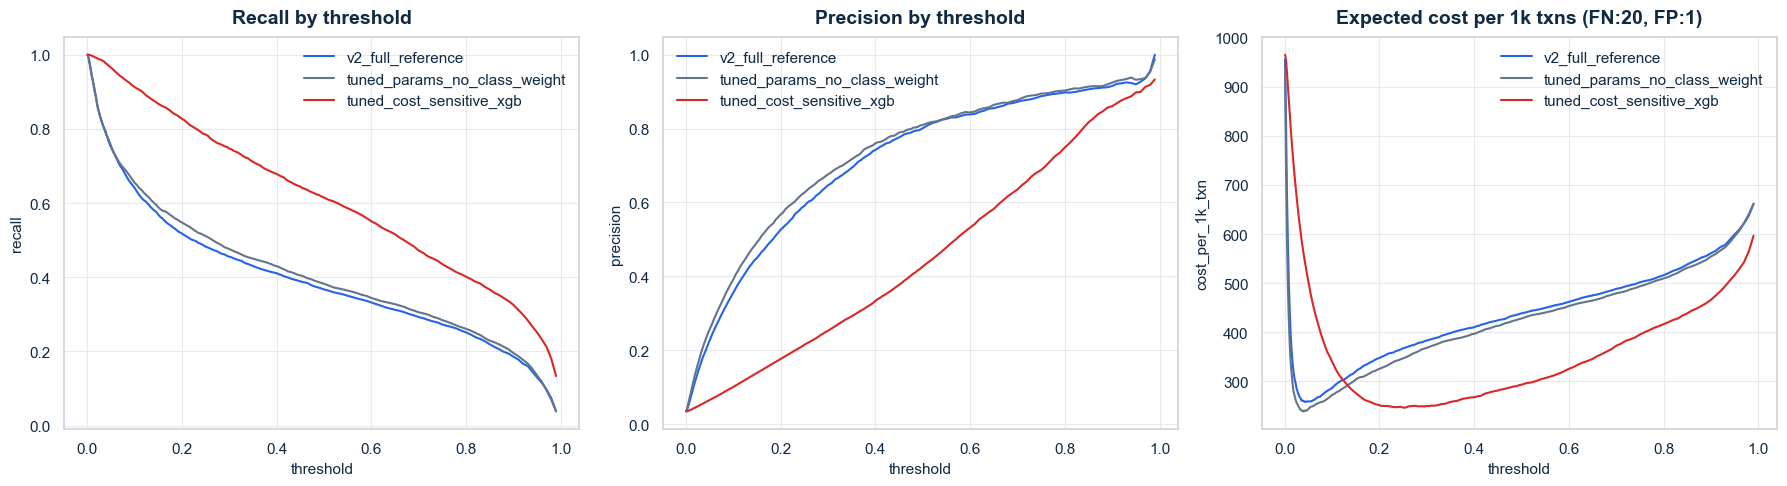

In [7]:
threshold_plot = pd.concat(threshold_tables.values(), ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="recall",
    hue="model",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[0],
)
axes[0].set_title("Recall by threshold")
axes[0].set_ylabel("recall")

sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="precision",
    hue="model",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[1],
)
axes[1].set_title("Precision by threshold")
axes[1].set_ylabel("precision")

sns.lineplot(
    data=threshold_plot,
    x="threshold",
    y="cost_per_1k_txn",
    hue="model",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[2],
)
axes[2].set_title(f"Expected cost per 1k txns (FN:{FN_COST}, FP:{FP_COST})")
axes[2].set_ylabel("cost_per_1k_txn")

for ax in axes:
    ax.set_xlabel("threshold")
    ax.legend(title="")

plt.tight_layout()
plt.show()


## Confusion Matrices At Optimized Thresholds

Matrix layout is intentionally business-facing:

- rows are actual labels
- columns are predicted labels
- top-left is `TP`

This makes the missed-fraud count easy to read from the top-right cell.


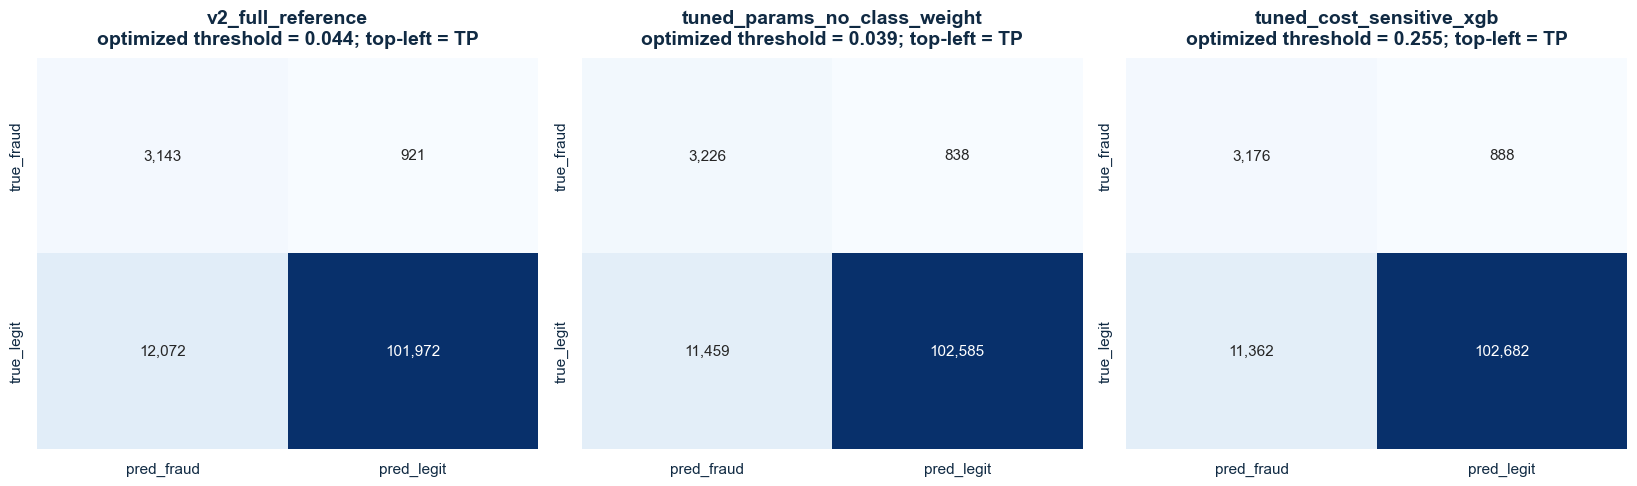

In [8]:
def confusion_counts_at_threshold(y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return confusion_matrix(y_true, y_pred, labels=[1, 0])


fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5.5 * len(MODEL_ORDER), 5))

for ax, row in zip(axes, selected_thresholds.set_index("model").loc[MODEL_ORDER].reset_index().itertuples(index=False)):
    model_name = row.model
    matrix = confusion_counts_at_threshold(y_valid, score_by_model[model_name], row.threshold)

    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        xticklabels=["pred_fraud", "pred_legit"],
        yticklabels=["true_fraud", "true_legit"],
        ax=ax,
    )
    ax.set_title(f"{model_name}\noptimized threshold = {row.threshold:.3f}; top-left = TP")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## Controlled Comparison At The Tuned Threshold

The optimized threshold is model-specific because each model has its own score scale.

Still, it is useful to hold the final tuned operating threshold fixed and apply it to both models. This is a simple control check for the chosen business policy.


model,threshold,true_positives,false_positives,false_negatives,true_negatives,precision,recall,false_positive_rate,false_negative_rate,review_rate,total_cost,cost_per_1k_txn,threshold_source
tuned_cost_sensitive_xgb,0.255000,3176,11362,888,102682,0.218462,0.781496,0.099628,0.218504,0.123091,29122,246.570935,tuned_cost_sensitive_xgb
tuned_params_no_class_weight,0.255000,2065,1202,1999,112842,0.632078,0.508120,0.010540,0.491880,0.027661,41182,348.680868,tuned_cost_sensitive_xgb
v2_full_reference,0.255000,1952,1313,2112,112731,0.597856,0.480315,0.011513,0.519685,0.027644,43553,368.755715,tuned_cost_sensitive_xgb


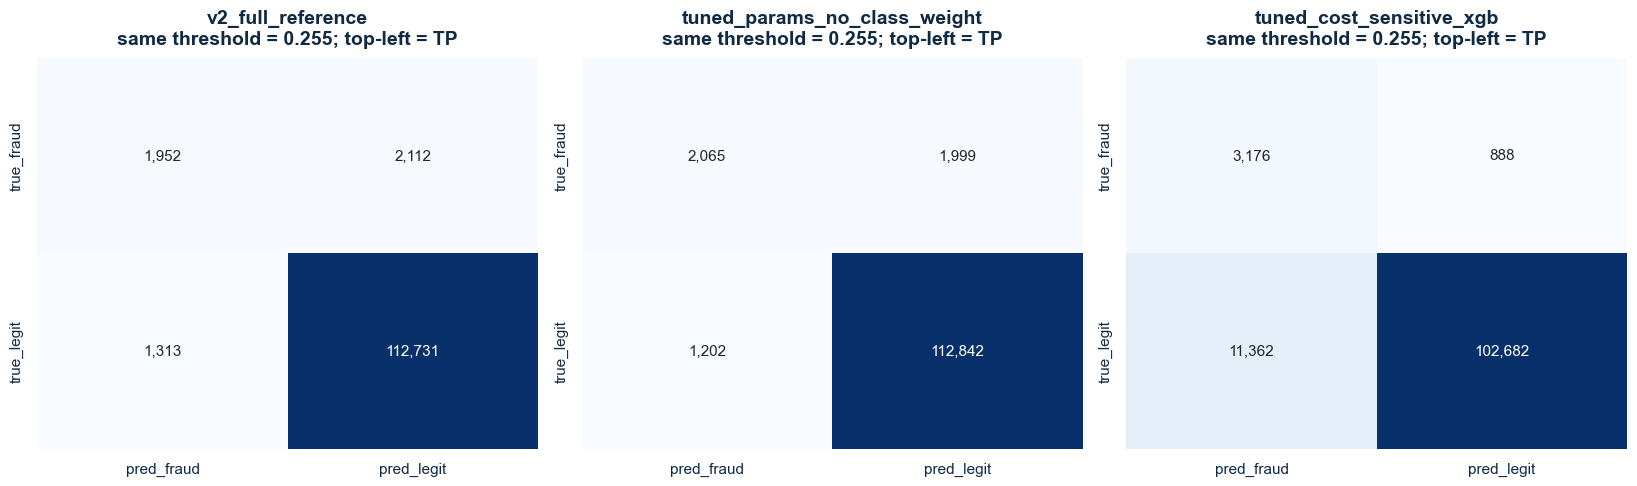

In [9]:
tuned_threshold = float(
    selected_thresholds.loc[
        selected_thresholds["model"] == "tuned_cost_sensitive_xgb",
        "threshold",
    ].iloc[0]
)

fixed_threshold_rows = []
for model_name, scores in score_by_model.items():
    row = threshold_policy_table(
        y_valid,
        scores,
        model_name,
        thresholds=[tuned_threshold],
        fn_cost=FN_COST,
        fp_cost=FP_COST,
    ).iloc[0].to_dict()
    row["threshold_source"] = "tuned_cost_sensitive_xgb"
    fixed_threshold_rows.append(row)

fixed_tuned_threshold_comparison = pd.DataFrame(fixed_threshold_rows).sort_values("total_cost")
display(fixed_tuned_threshold_comparison.style.hide(axis="index"))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(5.5 * len(MODEL_ORDER), 5))
for ax, row in zip(axes, fixed_tuned_threshold_comparison.set_index("model").loc[MODEL_ORDER].reset_index().itertuples(index=False)):
    matrix = confusion_counts_at_threshold(y_valid, score_by_model[row.model], tuned_threshold)
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        xticklabels=["pred_fraud", "pred_legit"],
        yticklabels=["true_fraud", "true_legit"],
        ax=ax,
    )
    ax.set_title(f"{row.model}\nsame threshold = {tuned_threshold:.3f}; top-left = TP")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


## Review Budget View


model,review_fraction,review_count,true_positives,false_positives,false_negatives,true_negatives,precision,recall
v2_full_reference,0.010000,1182,1058,124,3006,113920,0.895093,0.260335
v2_full_reference,0.030000,3544,2018,1526,2046,112518,0.569413,0.496555
v2_full_reference,0.050000,5906,2433,3473,1631,110571,0.411954,0.598671
v2_full_reference,0.100000,11811,2968,8843,1096,105201,0.251291,0.730315
tuned_params_no_class_weight,0.010000,1182,1067,115,2997,113929,0.902707,0.262549
tuned_params_no_class_weight,0.030000,3544,2130,1414,1934,112630,0.601016,0.524114
tuned_params_no_class_weight,0.050000,5906,2562,3344,1502,110700,0.433796,0.630413
tuned_params_no_class_weight,0.100000,11811,3062,8749,1002,105295,0.259250,0.753445
tuned_cost_sensitive_xgb,0.010000,1182,1055,127,3009,113917,0.892555,0.259596
tuned_cost_sensitive_xgb,0.030000,3544,2077,1467,1987,112577,0.586061,0.511073


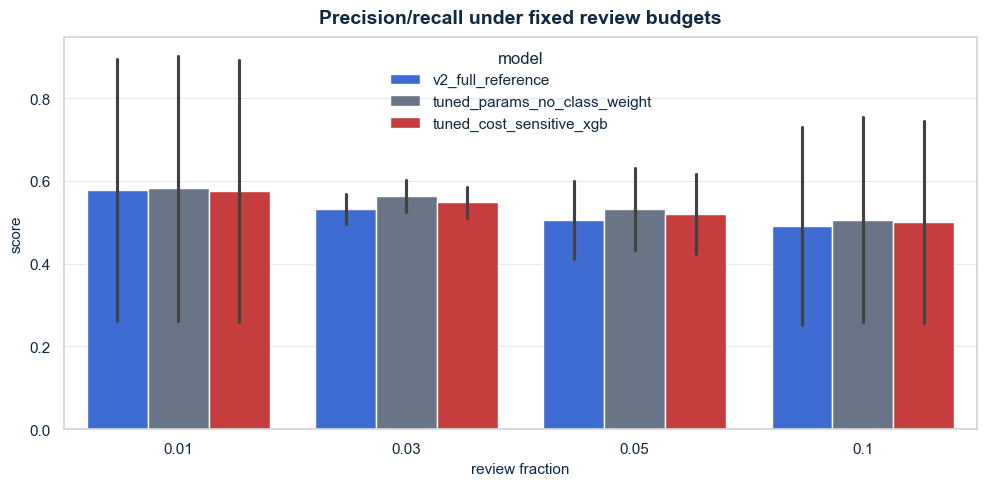

In [10]:
def review_budget_table(y_true, y_score, model_name, fractions=(0.01, 0.03, 0.05, 0.10)):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    rows = []

    for fraction in fractions:
        n_select = max(1, int(np.ceil(len(y_score) * fraction)))
        selected_idx = np.argsort(-y_score)[:n_select]
        selected = np.zeros(len(y_score), dtype=bool)
        selected[selected_idx] = True

        tp = int(np.sum(selected & (y_true == 1)))
        fp = int(np.sum(selected & (y_true == 0)))
        fn = int(np.sum((~selected) & (y_true == 1)))
        tn = int(np.sum((~selected) & (y_true == 0)))

        rows.append(
            {
                "model": model_name,
                "review_fraction": fraction,
                "review_count": n_select,
                "true_positives": tp,
                "false_positives": fp,
                "false_negatives": fn,
                "true_negatives": tn,
                "precision": tp / max(1, tp + fp),
                "recall": tp / max(1, tp + fn),
            }
        )

    return pd.DataFrame(rows)


review_budget = pd.concat(
    [
        review_budget_table(y_valid, scores, model_name)
        for model_name, scores in score_by_model.items()
    ],
    ignore_index=True,
)
display(review_budget.style.hide(axis="index"))

budget_plot = review_budget.melt(
    id_vars=["model", "review_fraction"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=budget_plot,
    x="review_fraction",
    y="value",
    hue="model",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
)
plt.title("Precision/recall under fixed review budgets")
plt.xlabel("review fraction")
plt.ylabel("score")
plt.tight_layout()
plt.show()


## Cost Ratio Sensitivity


fn_cost,fp_cost,model,threshold,true_positives,false_positives,false_negatives,true_negatives,precision,recall,review_rate,cost_per_1k_txn
5,1,tuned_params_no_class_weight,0.170000,2331,2106,1733,111938,0.525355,0.573573,0.037567,91.196193
5,1,tuned_cost_sensitive_xgb,0.560000,2359,2456,1705,111588,0.489927,0.580463,0.040768,92.974227
5,1,v2_full_reference,0.145000,2346,2937,1718,111107,0.444066,0.577264,0.044730,97.597115
10,1,tuned_params_no_class_weight,0.085000,2774,5024,1290,109020,0.355732,0.682579,0.066024,151.759407
10,1,tuned_cost_sensitive_xgb,0.415000,2721,5129,1343,108915,0.346624,0.669537,0.066465,157.135842
10,1,v2_full_reference,0.075000,2810,6688,1254,107356,0.295852,0.691437,0.080418,162.800149
20,1,tuned_params_no_class_weight,0.039000,3226,11459,838,102585,0.219680,0.793799,0.124335,238.925390
20,1,tuned_cost_sensitive_xgb,0.255000,3176,11362,888,102682,0.218462,0.781496,0.123091,246.570935
20,1,v2_full_reference,0.044000,3143,12072,921,101972,0.206572,0.773376,0.128823,258.170488


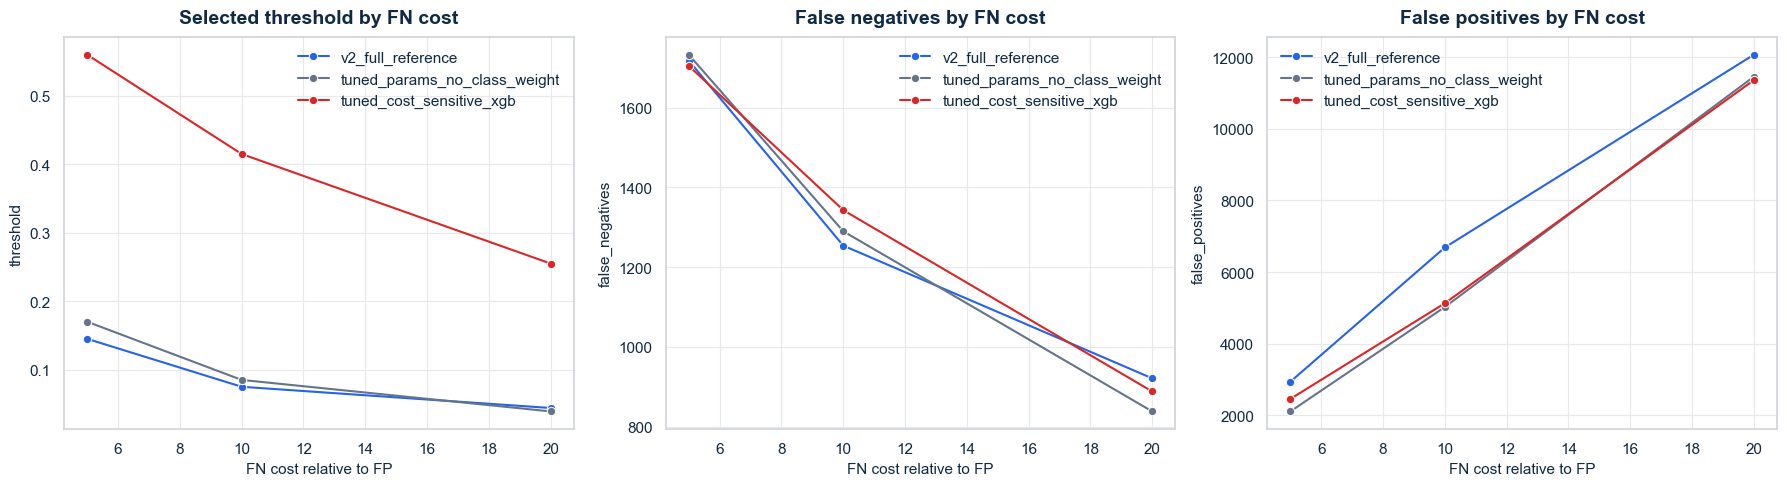

In [11]:
sensitivity_rows = []
for fn_cost in [5, 10, 20]:
    for model_name, scores in score_by_model.items():
        table = threshold_policy_table(
            y_valid,
            scores,
            model_name,
            fn_cost=fn_cost,
            fp_cost=1,
        )
        best_row = table.sort_values(
            ["total_cost", "false_negatives", "review_rate"],
            ascending=[True, True, True],
        ).iloc[0].to_dict()
        best_row["fn_cost"] = fn_cost
        best_row["fp_cost"] = 1
        sensitivity_rows.append(best_row)

cost_sensitivity = pd.DataFrame(sensitivity_rows)
display(
    cost_sensitivity[
        [
            "fn_cost",
            "fp_cost",
            "model",
            "threshold",
            "true_positives",
            "false_positives",
            "false_negatives",
            "true_negatives",
            "precision",
            "recall",
            "review_rate",
            "cost_per_1k_txn",
        ]
    ].sort_values(["fn_cost", "cost_per_1k_txn"]).style.hide(axis="index")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=cost_sensitivity,
    x="fn_cost",
    y="threshold",
    hue="model",
    marker="o",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[0],
)
axes[0].set_title("Selected threshold by FN cost")
axes[0].set_xlabel("FN cost relative to FP")

sns.lineplot(
    data=cost_sensitivity,
    x="fn_cost",
    y="false_negatives",
    hue="model",
    marker="o",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[1],
)
axes[1].set_title("False negatives by FN cost")
axes[1].set_xlabel("FN cost relative to FP")

sns.lineplot(
    data=cost_sensitivity,
    x="fn_cost",
    y="false_positives",
    hue="model",
    marker="o",
    palette=MODEL_COLORS,
    hue_order=MODEL_ORDER,
    ax=axes[2],
)
axes[2].set_title("False positives by FN cost")
axes[2].set_xlabel("FN cost relative to FP")

for ax in axes:
    ax.legend(title="")

plt.tight_layout()
plt.show()


## Final Operating Point Report

After choosing the business threshold, report both model-quality metrics and operating metrics.

This makes the final decision clear: the tuned model is allowed to flag more legitimate transactions only if it reduces missed fraud and expected cost.


In [12]:
final_operating_report = selected_thresholds.merge(
    model_metrics[
        [
            "model",
            "roc_auc",
            "pr_auc_average_precision",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
        ]
    ],
    on="model",
    how="left",
)
display(
    final_operating_report[
        [
            "model",
            "threshold",
            "roc_auc",
            "pr_auc_average_precision",
            "true_positives",
            "false_positives",
            "false_negatives",
            "true_negatives",
            "precision",
            "recall",
            "false_positive_rate",
            "false_negative_rate",
            "review_rate",
            "cost_per_1k_txn",
        ]
    ].style.hide(axis="index")
)

tuned_final = final_operating_report.loc[
    final_operating_report["model"] == "tuned_cost_sensitive_xgb"
].iloc[0]
reference_final = final_operating_report.loc[
    final_operating_report["model"] == "v2_full_reference"
].iloc[0]

final_delta = pd.DataFrame(
    [
        {
            "comparison": "tuned_minus_v2_full_reference",
            "auroc_delta": tuned_final["roc_auc"] - reference_final["roc_auc"],
            "pr_auc_delta": tuned_final["pr_auc_average_precision"] - reference_final["pr_auc_average_precision"],
            "true_positive_delta": tuned_final["true_positives"] - reference_final["true_positives"],
            "false_positive_delta": tuned_final["false_positives"] - reference_final["false_positives"],
            "false_negative_delta": tuned_final["false_negatives"] - reference_final["false_negatives"],
            "review_rate_delta": tuned_final["review_rate"] - reference_final["review_rate"],
            "cost_per_1k_delta": tuned_final["cost_per_1k_txn"] - reference_final["cost_per_1k_txn"],
        }
    ]
)
display(final_delta.style.hide(axis="index"))

class_weight_delta = pd.DataFrame(
    [
        {
            "comparison": "cost_sensitive_minus_same_params_no_weight",
            "auroc_delta": tuned_final["roc_auc"]
            - final_operating_report.loc[
                final_operating_report["model"] == "tuned_params_no_class_weight",
                "roc_auc",
            ].iloc[0],
            "pr_auc_delta": tuned_final["pr_auc_average_precision"]
            - final_operating_report.loc[
                final_operating_report["model"] == "tuned_params_no_class_weight",
                "pr_auc_average_precision",
            ].iloc[0],
            "false_positive_delta": tuned_final["false_positives"]
            - final_operating_report.loc[
                final_operating_report["model"] == "tuned_params_no_class_weight",
                "false_positives",
            ].iloc[0],
            "false_negative_delta": tuned_final["false_negatives"]
            - final_operating_report.loc[
                final_operating_report["model"] == "tuned_params_no_class_weight",
                "false_negatives",
            ].iloc[0],
            "cost_per_1k_delta": tuned_final["cost_per_1k_txn"]
            - final_operating_report.loc[
                final_operating_report["model"] == "tuned_params_no_class_weight",
                "cost_per_1k_txn",
            ].iloc[0],
        }
    ]
)
display(class_weight_delta.style.hide(axis="index"))


model,threshold,roc_auc,pr_auc_average_precision,true_positives,false_positives,false_negatives,true_negatives,precision,recall,false_positive_rate,false_negative_rate,review_rate,cost_per_1k_txn
tuned_params_no_class_weight,0.039000,0.924168,0.583864,3226,11459,838,102585,0.219680,0.793799,0.100479,0.206201,0.124335,238.925390
tuned_cost_sensitive_xgb,0.255000,0.921506,0.569229,3176,11362,888,102682,0.218462,0.781496,0.099628,0.218504,0.123091,246.570935
v2_full_reference,0.044000,0.911789,0.553101,3143,12072,921,101972,0.206572,0.773376,0.105854,0.226624,0.128823,258.170488


comparison,auroc_delta,pr_auc_delta,true_positive_delta,false_positive_delta,false_negative_delta,review_rate_delta,cost_per_1k_delta
tuned_minus_v2_full_reference,0.009717,0.016128,33,-710,-33,-0.005732,-11.599553


comparison,auroc_delta,pr_auc_delta,false_positive_delta,false_negative_delta,cost_per_1k_delta
cost_sensitive_minus_same_params_no_weight,-0.002662,-0.014635,-97,50,7.645545


## Reading The Result


In [13]:
tuned_metrics = model_metrics.loc[model_metrics["model"] == "tuned_cost_sensitive_xgb"].iloc[0]
ref_metrics = model_metrics.loc[model_metrics["model"] == "v2_full_reference"].iloc[0]
no_weight_metrics = model_metrics.loc[model_metrics["model"] == "tuned_params_no_class_weight"].iloc[0]

tuned_policy = selected_thresholds.loc[selected_thresholds["model"] == "tuned_cost_sensitive_xgb"].iloc[0]
ref_policy = selected_thresholds.loc[selected_thresholds["model"] == "v2_full_reference"].iloc[0]
no_weight_policy = selected_thresholds.loc[selected_thresholds["model"] == "tuned_params_no_class_weight"].iloc[0]

best_policy = selected_thresholds.sort_values(
    ["cost_per_1k_txn", "false_negatives", "false_positives"],
    ascending=[True, True, True],
).iloc[0]

decision_summary = pd.DataFrame(
    [
        {
            "question": "Does tuned improve PR-AUC?",
            "answer": tuned_metrics["pr_auc_average_precision"] - ref_metrics["pr_auc_average_precision"],
        },
        {
            "question": "Does tuned improve AUROC?",
            "answer": tuned_metrics["roc_auc"] - ref_metrics["roc_auc"],
        },
        {
            "question": "Does tuned reduce optimized expected cost?",
            "answer": ref_policy["cost_per_1k_txn"] - tuned_policy["cost_per_1k_txn"],
        },
        {
            "question": "Does tuned reduce false negatives at optimized threshold?",
            "answer": ref_policy["false_negatives"] - tuned_policy["false_negatives"],
        },
        {
            "question": "Does class weighting improve PR-AUC over same tuned params?",
            "answer": tuned_metrics["pr_auc_average_precision"] - no_weight_metrics["pr_auc_average_precision"],
        },
        {
            "question": "Does class weighting reduce optimized expected cost over same tuned params?",
            "answer": no_weight_policy["cost_per_1k_txn"] - tuned_policy["cost_per_1k_txn"],
        },
        {
            "question": "Best model under selected business cost policy",
            "answer": best_policy["model"],
        },
    ]
)
display(decision_summary.style.hide(axis="index"))

recommendation = (
    f"Use {best_policy['model']} at threshold {best_policy['threshold']:.3f} "
    f"for this FN:{FN_COST}, FP:{FP_COST} business policy."
)

print(recommendation)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(
        {
            "model_metrics": model_metrics.to_dict(orient="records"),
            "generalization_metrics": generalization_metrics.to_dict(orient="records"),
            "selected_thresholds": selected_thresholds.to_dict(orient="records"),
            "fixed_tuned_threshold_comparison": fixed_tuned_threshold_comparison.to_dict(orient="records"),
            "final_operating_report": final_operating_report.to_dict(orient="records"),
            "review_budget": review_budget.to_dict(orient="records"),
            "cost_sensitivity": cost_sensitivity.to_dict(orient="records"),
            "recommendation": recommendation,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print(f"Saved {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


question,answer
Does tuned improve PR-AUC?,0.016128
Does tuned improve AUROC?,0.009717
Does tuned reduce optimized expected cost?,11.599553
Does tuned reduce false negatives at optimized threshold?,33
Does class weighting improve PR-AUC over same tuned params?,-0.014635
Does class weighting reduce optimized expected cost over same tuned params?,-7.645545
Best model under selected business cost policy,tuned_params_no_class_weight


Use tuned_params_no_class_weight at threshold 0.039 for this FN:20, FP:1 business policy.
Saved outputs/business_threshold_selection_summary.json
